In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df =pd.read_csv("F:\\PYTHON PROJ\\LEARN PYTHON\Customer Churn Prediction\\churn_cleaned.csv")

 
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_6-12m,tenure_group_1-2y,tenure_group_2-3y,tenure_group_3-5y,tenure_group_5-6y
0,0,0,1,0,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
3,1,0,0,0,45,0,0,1,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,2,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


Step 1. Data checking

Check data file making sure
1. No obj types in data
2. no missig values in the df
3. make clear of target: Churn  

In [12]:
df.dtypes
df.describe()



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_6-12m,tenure_group_1-2y,tenure_group_2-3y,tenure_group_3-5y,tenure_group_5-6y
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,...,0.209144,0.240664,0.216101,0.335794,0.228880,0.100099,0.145393,0.118131,0.226324,0.199773
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,...,0.406726,0.427517,0.411613,0.472301,0.420141,0.300154,0.352521,0.322787,0.418481,0.399858
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  StreamingTV    

In [14]:
df['Churn'].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64


Step 2. Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = df.drop('Churn',axis=1)


In [17]:
y=df['Churn']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state= 42, stratify=y)



2. 1 Split the trainand test set with 80% train and 20% test. 
random__state to fix the random seed to make the experiment duplicatable
stratify to make sure the churn rate in both sets are same to the population

check the sets stats

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 31)
(1409, 31)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


2.2 train use fit and transform operation. 
test use transform operation

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)



In [21]:
print(np.mean(X_train[:,0]))
print(np.std(X_train[:,0]))

1.1350522935464859e-16
1.0


mean ≈ 0
std ≈ 1

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, f1_score 

model = LogisticRegression(max_iter=4000)
model.fit(X_train, y_train)

y_pred= model.predict(X_test)
y_prob =model.predict_proba(X_test)[:,1]

In [23]:
 

cm= confusion_matrix(y_test, y_pred)

cm



array([[933, 102],
       [172, 202]])

In [24]:
precision_1 = cm[1,1]/cm[:,1].sum() #manual cal of precision for positive
recall_1 = cm[1,1]/cm[1,:].sum()#manual cal of recall for positive, the portion your predict catch the positive

precision_2 = cm[0,0]/cm[:,0].sum()
recall_2 = cm[0,0]/cm[1,:]

print("precision is ", precision_1)
print(precision_2)

print(recall_1)
print(recall_2)

precision is  0.6644736842105263
0.8443438914027149
0.5401069518716578
[5.4244186  4.61881188]


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



2.3 Logistics model performance

churn prediction：
For non churn customer
1. the model precision is good and high recall. Can catch most non churn customer

For churn customer
1. precision for positive is 0.66  decent better than guess
2. recall for positive is 0.54   also cannot caught enough real churn almost simalr to guess
3. acurracy is 0.81 though its not a good model since recall is high (Imagin i use a machine to predict all negative, only 374 are wrong (FN). accuracy is 0.73 ) Accuracy 会被“多数类”骗 Recall 才是真正业务指标

The rason why is not performing well

1. customer behavior is not linear 
2. 

👉 Random Forest 更适合

In [26]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.844865535146865

visualization of ROC curve  

In [27]:
from sklearn.metrics import roc_curve

fpr,tpr,_=roc_curve(y_test, y_prob)

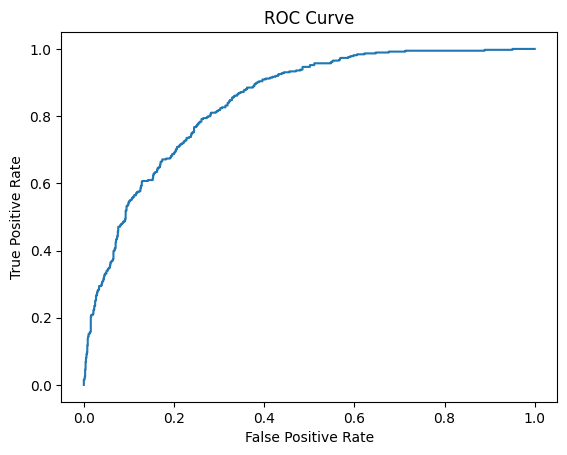

In [28]:
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

We can change the threshhold to improve the model


In [29]:
threshold = 0.3

y_pred_new= (y_prob >= threshold).astype(int)

In [30]:
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



we can see if we change the threshhold to 0.3, we have the model improved since recall is higher

more sceientic approach. We can search for the best threshold with maximum f1 score

In [31]:
thresholds = np.arange(0.1, 0.9, 0.005)

In [32]:
best_threashhold= 0
best_f1=0

for t in thresholds:
    y_pred_t = (y_prob>t).astype(int)
    f_1 = f1_score(y_test, y_pred_t)

    if(f_1 > best_f1):
        best_f1=f_1
        best_threashhold=t
    
print(f"Best threshold:{best_threashhold:.2f}")
print(f"Best f1 score: {best_f1:.2f}")    

     

Best threshold:0.28
Best f1 score: 0.63


we can also do it for maximizing the recall

In [33]:
from sklearn.metrics  import  recall_score
best_rthreashhold= 0
best_recall=0

for t in thresholds:
    y_pred_t = (y_prob>t).astype(int)
    recall = recall_score(y_test, y_pred_t)

    if(recall > best_recall):
        best_recall=recall
        best_rthreashhold=t
    
print(f"Best r_threshold:{best_rthreashhold:.2f}")
print(f"Best recall score: {best_recall:.2f}")    


Best r_threshold:0.10
Best recall score: 0.95


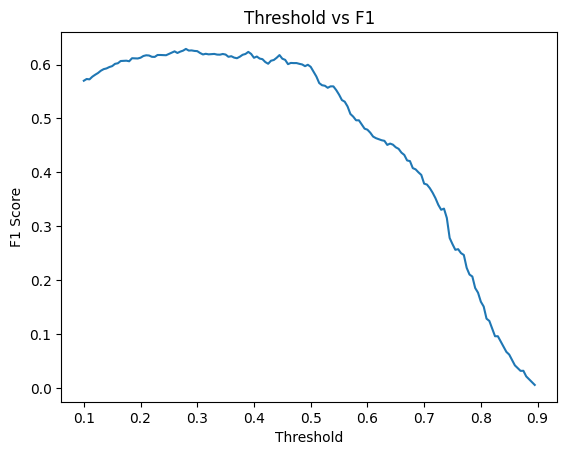

In [34]:
import matplotlib.pyplot as plt

f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1")
plt.show()

Step 3. Improve use Random Forest

3.1 Get original data without scaler

In [35]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X,y, test_size = 0.2, random_state= 42, stratify=y)

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
n_estimators=100,
max_depth=5,
random_state=42
)
rf.fit(X_train_r, y_train_r)

y_pred_rf = rf.predict(X_test_r)
y_prob_rf = rf.predict_proba(X_test_r)[:,1]

In [37]:
print(confusion_matrix(y_test_r, y_pred_rf))
print("Random Forest")
print(classification_report(y_test_r, y_pred_rf))

[[961  74]
 [227 147]]
Random Forest
              precision    recall  f1-score   support

           0       0.81      0.93      0.86      1035
           1       0.67      0.39      0.49       374

    accuracy                           0.79      1409
   macro avg       0.74      0.66      0.68      1409
weighted avg       0.77      0.79      0.77      1409



In [38]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_r, y_train_r)

y_pred_rf = rf.predict(X_test_r)
y_prob_rf = rf.predict_proba(X_test_r)[:,1]

max_depth from 5 to 10, and class_weight is balanced the recall increased signifcantly

In [39]:
print(confusion_matrix(y_test_r, y_pred_rf))

[[821 214]
 [106 268]]


In [40]:
print("Logistic Regression")
print(classification_report(y_test, y_pred))

print("Random Forest")
print(classification_report(y_test_r, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

Random Forest
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



Random forsest is even worse! Lets do thresh hold optimization!

In [41]:
from sklearn.metrics  import  recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

best_RF_threashhold= 0
best_RF_recall=0

best_RF_f1 =0
best_RF_f1threashhold= 0


for t in thresholds:
    y_pred_t = (y_prob_rf>t).astype(int)
    recall = recall_score(y_test_r, y_pred_t)
    f1 = f1_score(y_test_r, y_pred_t)
    precision = precision_score(y_test_r, y_pred_t)
    accuracy = accuracy_score(y_test_r, y_pred_t)

    print(f"t={t:.2f}| recall = {recall:.3f}| f1={f1:.3f}| precsion={precision:.3f}| accuracy={accuracy:.3f}" )
          
    if(recall > best_RF_recall):
        best_RF_recall=recall
        best_RF_threashhold=t
    
    if(f1>best_RF_f1):
        best_RF_f1threashhold=t
        best_RF_f1 = f1


print(f"\n Best r_f1_threshold:{best_RF_f1threashhold:.3f}")
print(f"Best f1 score: {best_RF_f1:.3f}")    

print(f"\n Best r_threshold:{best_RF_threashhold:.3f}")
print(f"Best recall score: {best_RF_recall:.3f}")  

t=0.10| recall = 0.971| f1=0.513| precsion=0.349| accuracy=0.512
t=0.11| recall = 0.968| f1=0.516| precsion=0.352| accuracy=0.519
t=0.11| recall = 0.968| f1=0.521| precsion=0.356| accuracy=0.527
t=0.12| recall = 0.968| f1=0.525| precsion=0.360| accuracy=0.535
t=0.12| recall = 0.963| f1=0.526| precsion=0.362| accuracy=0.540
t=0.13| recall = 0.957| f1=0.527| precsion=0.364| accuracy=0.544
t=0.13| recall = 0.955| f1=0.531| precsion=0.368| accuracy=0.552
t=0.14| recall = 0.952| f1=0.535| precsion=0.372| accuracy=0.561
t=0.14| recall = 0.952| f1=0.537| precsion=0.374| accuracy=0.564
t=0.15| recall = 0.952| f1=0.541| precsion=0.378| accuracy=0.571
t=0.15| recall = 0.952| f1=0.546| precsion=0.383| accuracy=0.581
t=0.16| recall = 0.952| f1=0.551| precsion=0.387| accuracy=0.588
t=0.16| recall = 0.952| f1=0.556| precsion=0.393| accuracy=0.596
t=0.17| recall = 0.947| f1=0.557| precsion=0.395| accuracy=0.601
t=0.17| recall = 0.944| f1=0.561| precsion=0.399| accuracy=0.608
t=0.18| recall = 0.941| f

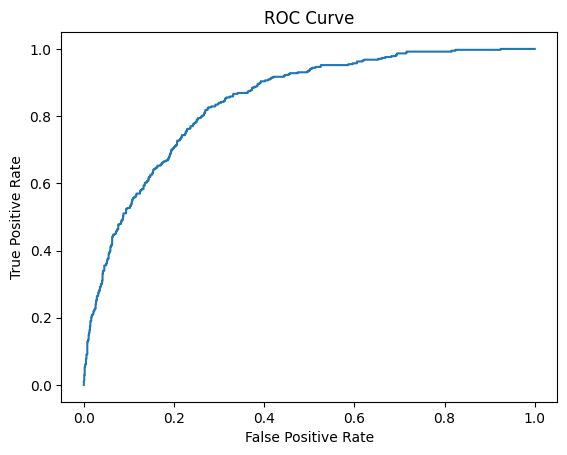

In [42]:
fpr,tpr,_=roc_curve(y_test_r, y_prob_rf)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

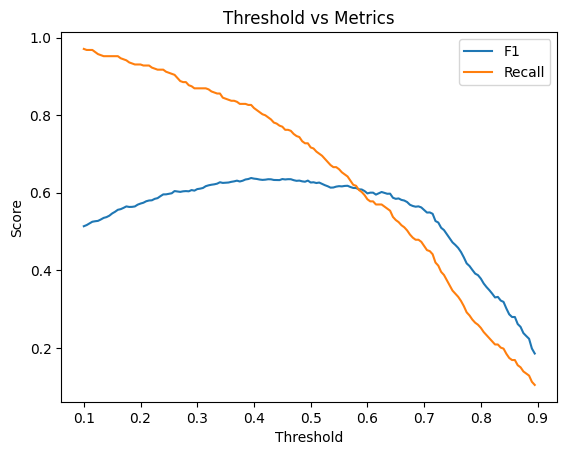

In [43]:
f1_list = []
recall_list = []

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)
    f1_list.append(f1_score(y_test_r, y_pred_t))
    recall_list.append(recall_score(y_test_r, y_pred_t))

plt.figure()
plt.plot(thresholds, f1_list, label='F1')
plt.plot(thresholds, recall_list, label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Metrics")
plt.legend()
plt.show()

STEP 4 Feature importance

In [44]:

feature_importances = rf.feature_importances_


importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})


importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                           Feature  Importance
4                           tenure    0.143408
15                    TotalCharges    0.121160
14                  MonthlyCharges    0.099448
16                      AvgCharges    0.096244
22               Contract_Two year    0.088273
19     InternetService_Fiber optic    0.064399
24  PaymentMethod_Electronic check    0.049136
21               Contract_One year    0.039039
20              InternetService_No    0.032510
30               tenure_group_5-6y    0.026118


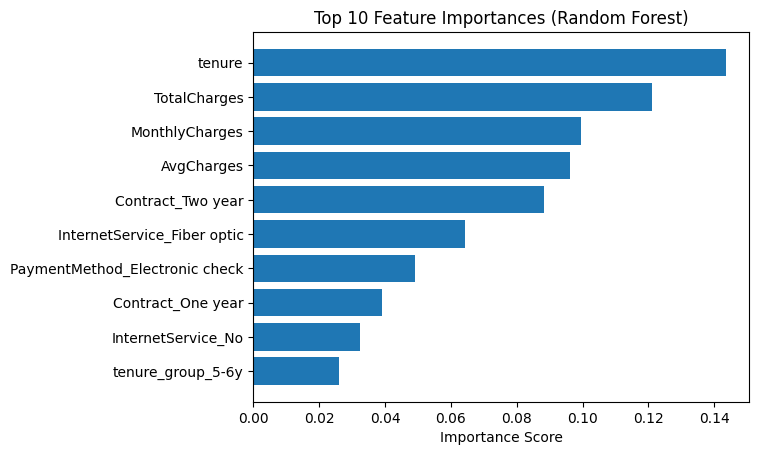

In [45]:
import matplotlib.pyplot as plt

top_n = 10
top_features = importance_df.head(top_n)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

Random Forest not only improved prediction performance but also provided valuable business insights into key drivers of churn.

Step 4. Refeautre Engineering 
we need to restruce our feature engineering to further imporve the f1 score to be above 0.7. Now lets get back to the dataset

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  StreamingTV    